# Промпт:
```
Ты — Data Scientist. Мне нужно создать Python-приложение в формате Jupyter Notebook для классификации сетевого трафика на нормальный (Normal) и вредоносный (DDoS). 

Входные данные:
Датасет содержит следующие признаки: Unnamed: 0, pkSeqID, stime, flgs, flgs_number, proto, proto_number, saddr, sport, daddr, dport, pkts, bytes, state, state_number, ltime, seq, dur, mean, stddev, sum, min, max, spkts, dpkts, sbytes, dbytes, rate, srate, drate, TnBPSrcIP, TnBPDstIP, TnP_PSrcIP, TnP_PDstIP, TnP_PerProto, TnP_Per_Dport, AR_P_Proto_P_SrcIP, AR_P_Proto_P_DstIP, N_IN_Conn_P_DstIP, N_IN_Conn_P_SrcIP, AR_P_Proto_P_Sport, AR_P_Proto_P_Dport, Pkts_P_State_P_Protocol_P_DestIP, Pkts_P_State_P_Protocol_P_SrcIP, attack, category, subcategory.

Целевая переменная: 'category' (принимает значения 'DDoS' или 'Normal'). В датасете присутствует критический дисбаланс классов: около 2 000 000 записей DDoS и всего около 500 записей Normal.

Твоя задача — предложить решение и написать код, разбив его на логические блоки (ячейки Jupyter Notebook) такие, как загрузка и анализ данных, подготовка данных к обучению (что удалить, как работать с дисбалансом), обучение минимум двух моделей и оценка результатов с демонстрацией матрицы ошибок и сохранением результата в result.csv
```

In [3]:
# !pip install imbalanced-learn lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


Размер датасета: 1927101 строк, 47 признаков

Распределение классов в 'category':
category
DDoS      1926624
Normal        477
Name: count, dtype: int64
--------------------------------------------------


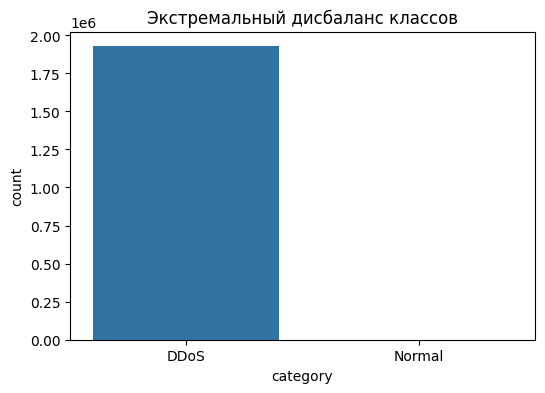

Пропущенные значения (только колонки с пропусками):
Series([], dtype: int64)


In [5]:
# Замени 'dataset.csv' на реальный путь к твоему файлу
df = pd.read_csv('DDoSdata.csv')

print(# Размеры
f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} признаков\n")

print("Распределение классов в 'category':")
print(df['category'].value_counts())
print("-" * 50)

# Визуализация дисбаланса
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='category')
plt.title("Экстремальный дисбаланс классов")
plt.show()

# Проверка пропусков
missing = df.isnull().sum()
print("Пропущенные значения (только колонки с пропусками):")
print(missing[missing > 0])

In [6]:
# 1. Выделяем таргет и признаки
X = df.drop(columns=['category'])
y = df['category']

# 2. Список колонок, которые нужно выкинуть (утечка данных или мусор)
columns_to_drop = ['Unnamed: 0', 'pkSeqID', 'saddr', 'daddr', 'sport', 'dport', 'attack', 'subcategory']
# Дропаем только те, которые реально есть в X (на случай, если каких-то уже нет)
X = X.drop(columns=[col for col in columns_to_drop if col in X.columns])

# 3. Борьба с дисбалансом через RandomUnderSampler
# Задаем стратегию: хотим, чтобы миноритарный класс составлял 10% от мажоритарного (соотношение 1:10)
# 'Normal' у нас ~500, значит 'DDoS' останется ~5000.
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print(f"Размер данных после undersampling: {X_resampled.shape}")
print("Новое распределение классов:")
print(y_resampled.value_counts())

Размер данных после undersampling: (5247, 38)
Новое распределение классов:
category
DDoS      4770
Normal     477
Name: count, dtype: int64


In [7]:
# Разделение на train/test со стратификацией (чтобы пропорция классов сохранилась)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# Определяем типы колонок
categorical_cols = ['proto', 'state', 'flgs']
# Все остальные колонки — числовые
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Создаем трансформер для колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

print("Пайплайн предобработки готов.")

Пайплайн предобработки готов.


=== Отчет для Random Forest ===
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00       955
      Normal       1.00      1.00      1.00        95

    accuracy                           1.00      1050
   macro avg       1.00      1.00      1.00      1050
weighted avg       1.00      1.00      1.00      1050

=== Отчет для LightGBM ===
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00       955
      Normal       1.00      1.00      1.00        95

    accuracy                           1.00      1050
   macro avg       1.00      1.00      1.00      1050
weighted avg       1.00      1.00      1.00      1050



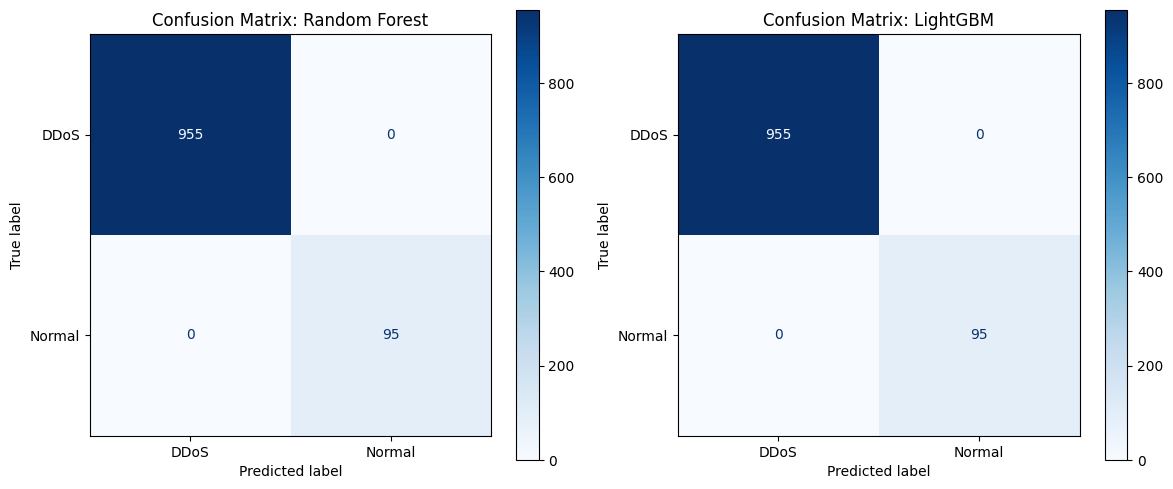

In [10]:
# Словарик для моделей
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

results = {}

# Цикл обучения и оценки
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate(models.items()):
    # Полный пайплайн: Предобработка -> Модель
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    # Обучение
    clf.fit(X_train, y_train)
    
    # Предсказание
    y_pred = clf.predict(X_test)
    
    # Считаем метрики
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = f1_macro
    
    print(f"=== Отчет для {name} ===")
    print(classification_report(y_test, y_pred))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

In [9]:
# Сохраняем результаты в CSV
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'F1_Score_Macro'])
df_results.to_csv('results.csv', index=False)
print("Результаты успешно сохранены в results.csv!")
df_results

Результаты успешно сохранены в results.csv!


,Model,F1_Score_Macro
0,Random Forest,1.0
1,LightGBM,1.0
